# Benchmarking Computational Tools for Bacteriophage Host Prediction in Arthrobacter species and Arthrobacter globiformis

**Varsha Upadhyayulla**

Introduction to Computational Biology


In [7]:
import os, ast, time, subprocess, warnings, random, gzip, shutil
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import product
from tqdm.notebook import tqdm
from urllib.request import urlretrieve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

warnings.filterwarnings('ignore')

dirs = {
    'fasta_arth':  'data/fasta_arthrobacter',
    'fasta_ref':   'data/fasta_ref_hosts',
    'wish_models': 'wish_models',
    'wish_out':    'wish_output',
    'figures':     'figures',
    'results':     'results',
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

In [8]:
url = 'https://phagesdb.org/api/phages/?page_size=10000'
response = requests.get(url, timeout=60)
phages = pd.DataFrame(response.json()['results'])
print(len(phages), 'phages retrieved')

10000 phages retrieved


In [9]:
def get_field(val, field):
    try:
        if isinstance(val, str):
            val = ast.literal_eval(val)
        return val.get(field, '').strip() if isinstance(val, dict) else ''
    except:
        return ''

phages['host_genus']   = phages['isolation_host'].apply(lambda x: get_field(x, 'genus'))
phages['host_species'] = phages['isolation_host'].apply(lambda x: get_field(x, 'species'))

arth_phages  = phages[phages['host_genus'] == 'Arthrobacter'].copy()
glob_phages  = phages[(phages['host_genus'] == 'Arthrobacter') &
                      (phages['host_species'].str.lower() == 'globiformis')].copy()
other_phages = phages[(phages['host_genus'] != 'Arthrobacter') &
                      (phages['host_genus'] != '')].copy()

print(f'Arthrobacter phages: {len(arth_phages)}')
print(f'A. globiformis:      {len(glob_phages)}')
print(f'Other genera:        {len(other_phages)}')

arth_phages.to_csv('results/arthrobacter_metadata.csv', index=False)
glob_phages.to_csv('results/globiformis_metadata.csv', index=False)

Arthrobacter phages: 996
A. globiformis:      676
Other genera:        9003


In [10]:
def fetch_seq(url, dest, timeout=20):
    try:
        if not url or pd.isna(url):
            return None
        r = requests.get(url, timeout=timeout)
        if r.status_code == 200 and len(r.text) > 100:
            with open(dest, 'w') as f:
                f.write(r.text)
            return ''.join(l for l in r.text.strip().split('\n')
                           if not l.startswith('>')).upper()
    except:
        pass
    return None

arth_seqs, arth_genus_labels, arth_species_labels = {}, {}, {}

for _, row in tqdm(arth_phages.iterrows(), total=len(arth_phages)):
    name = row['phage_name']
    dest = f"{dirs['fasta_arth']}/{name}.fasta"
    if os.path.exists(dest):
        seq = ''.join(l for l in open(dest).read().split('\n') if not l.startswith('>')).upper()
    else:
        seq = fetch_seq(row.get('fasta_file'), dest)
    if seq:
        arth_seqs[name] = seq
        arth_genus_labels[name] = 'Arthrobacter'
        arth_species_labels[name] = row['host_species']

other_sample = other_phages.sample(min(150, len(other_phages)), random_state=42)
other_seqs, other_genus_labels = {}, {}

for _, row in tqdm(other_sample.iterrows(), total=len(other_sample)):
    name = row['phage_name']
    dest = f"{dirs['fasta_arth']}/{name}.fasta"
    if os.path.exists(dest):
        seq = ''.join(l for l in open(dest).read().split('\n') if not l.startswith('>')).upper()
    else:
        seq = fetch_seq(row.get('fasta_file'), dest)
    if seq:
        other_seqs[name] = seq
        other_genus_labels[name] = row['host_genus']

print(f'Arthrobacter sequences: {len(arth_seqs)}')
print(f'Other sequences: {len(other_seqs)}')

  0%|          | 0/996 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Arthrobacter sequences: 244
Other sequences: 34


In [11]:
all_seqs   = {**arth_seqs, **other_seqs}
all_genus  = {**arth_genus_labels, **other_genus_labels}

n_glob = sum(1 for v in arth_species_labels.values() if v.lower() == 'globiformis')
print(f'Total (genus task): {len(all_seqs)}  |  A. globiformis: {n_glob}')

species_counts = Counter(arth_species_labels.values())
for sp, ct in species_counts.most_common(10):
    print(f'  {sp or "(unspecified)":<25} {ct}')

Total (genus task): 278  |  A. globiformis: 147
  globiformis               147
  sp.                       82
  sulfureus                 11
  atrocyaneus               3
  pascens                   1


Tool One: PHASTEST

In [12]:
PHASTEST_URL  = 'https://phastest.ca/phastest_api'
SAMPLE_SIZE   = 50
POLL_INTERVAL = 30

def submit_phastest(seq):
    try:
        r = requests.post(PHASTEST_URL, data={'sequence': f'>query\n{seq}'}, timeout=30)
        if r.status_code == 200:
            return r.json().get('job_id')
    except:
        pass
    return None

def poll_phastest(job_id, max_wait=300):
    start = time.time()
    while time.time() - start < max_wait:
        try:
            r = requests.get(f'{PHASTEST_URL}?acc={job_id}', timeout=20)
            if r.status_code == 200:
                j = r.json()
                if j.get('status') == 'Complete':
                    return j
                if j.get('status') in ('Failed', 'Error'):
                    return None
        except:
            pass
        time.sleep(POLL_INTERVAL)
    return None

def parse_host(result):
    if not result:
        return ('Unknown', 'Unknown')
    try:
        orgs = [hit.get('organism','') for r in result.get('regions',[])
                for hit in r.get('hits',[]) if hit.get('organism','')]
        if not orgs:
            return ('NoHit', 'NoHit')
        top = Counter(orgs).most_common(1)[0][0].split()
        return (top[0], top[1]) if len(top) >= 2 else (top[0], '')
    except:
        return ('Unknown', 'Unknown')

sample_names = random.sample(list(all_seqs.keys()), min(SAMPLE_SIZE, len(all_seqs)))
random.seed(42)

job_ids = {}
for name in tqdm(sample_names):
    jid = submit_phastest(all_seqs[name][:50000])
    if jid:
        job_ids[name] = jid
    time.sleep(1)

phastest_results = {}
for name, jid in tqdm(job_ids.items()):
    result = poll_phastest(jid)
    phastest_results[name] = parse_host(result)

print(f'{len(phastest_results)} results collected')

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

36 results collected


In [13]:
common = [n for n in phastest_results if n in all_genus]
y_true_pt = [1 if all_genus[n] == 'Arthrobacter' else 0 for n in common]
y_pred_pt = [1 if phastest_results[n][0] == 'Arthrobacter' else 0 for n in common]

phastest_genus_metrics = {
    'Top-1 Accuracy': round(accuracy_score(y_true_pt, y_pred_pt), 3),
    'Macro F1':       round(f1_score(y_true_pt, y_pred_pt, average='macro', zero_division=0), 3),
    'n': len(common),
}

glob_in_sample = [n for n in phastest_results if arth_species_labels.get(n,'').lower() == 'globiformis']
glob_correct   = sum(1 for n in glob_in_sample if 'globiformis' in phastest_results[n][1].lower())
phastest_species_metrics = {
    'Top-1 Accuracy': round(glob_correct / len(glob_in_sample), 3) if glob_in_sample else 0,
    'n': len(glob_in_sample),
}

print('Genus:', phastest_genus_metrics)
print('Species:', phastest_species_metrics)

Genus: {'Top-1 Accuracy': 0.111, 'Macro F1': 0.1, 'n': 36}
Species: {'Top-1 Accuracy': 0.0, 'n': 15}


Tool 2: k-mer Frequency + Random Forest

In [14]:
KMERS_4 = [''.join(p) for p in product('ACGT', repeat=4)]

def kmer_vector(seq, kmers):
    k = len(kmers[0])
    counts = Counter(seq[i:i+k] for i in range(len(seq)-k+1)
                     if all(c in 'ACGT' for c in seq[i:i+k]))
    total = sum(counts.values())
    if total == 0:
        return np.zeros(len(kmers))
    return np.array([counts.get(km, 0) / total for km in kmers])

X_genus_rows, y_genus_rows, genus_names = [], [], []
for name in tqdm(all_seqs):
    seq = all_seqs[name]
    if len(seq) < 5000:
        continue
    X_genus_rows.append(kmer_vector(seq, KMERS_4))
    y_genus_rows.append(1 if all_genus.get(name) == 'Arthrobacter' else 0)
    genus_names.append(name)

X_genus = np.array(X_genus_rows)
y_genus = np.array(y_genus_rows)
print(f'Genus matrix: {X_genus.shape}  (Arthrobacter={y_genus.sum()}, other={(y_genus==0).sum()})')

X_sp_rows, y_sp_rows, sp_names = [], [], []
for name in tqdm(arth_seqs):
    seq = arth_seqs[name]
    sp  = arth_species_labels.get(name, '').lower()
    if len(seq) < 5000 or sp == '':
        continue
    X_sp_rows.append(kmer_vector(seq, KMERS_4))
    y_sp_rows.append(1 if sp == 'globiformis' else 0)
    sp_names.append(name)

X_species = np.array(X_sp_rows)
y_species  = np.array(y_sp_rows)
print(f'Species matrix: {X_species.shape}  (globiformis={y_species.sum()}, other={(y_species==0).sum()})')

  0%|          | 0/278 [00:00<?, ?it/s]

Genus matrix: (278, 256)  (Arthrobacter=244, other=34)


  0%|          | 0/244 [00:00<?, ?it/s]

Species matrix: (244, 256)  (globiformis=147, other=97)


In [15]:
import time as _time

def run_rf_cv(X, y, cv_strategy='stratified'):
    rf = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                class_weight='balanced', random_state=42, n_jobs=-1)
    cv = LeaveOneOut() if cv_strategy == 'loo' else StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    t0 = _time.time()
    y_pred = cross_val_predict(rf, X, y, cv=cv)
    elapsed = _time.time() - t0
    return {
        'Top-1 Accuracy': round(accuracy_score(y, y_pred), 3),
        'Macro F1':       round(f1_score(y, y_pred, average='macro', zero_division=0), 3),
        'Runtime/genome': round(elapsed / len(y), 4),
        'n': len(y),
        'y_true': y,
        'y_pred': y_pred,
    }

rf_genus_metrics   = run_rf_cv(X_genus, y_genus, cv_strategy='stratified')
print('Genus:', {k:v for k,v in rf_genus_metrics.items() if k not in ('y_true','y_pred')})

if y_species.sum() >= 2:
    strat = 'loo' if y_species.sum() < 20 else 'stratified'
    rf_species_metrics = run_rf_cv(X_species, y_species, cv_strategy=strat)
    print('Species:', {k:v for k,v in rf_species_metrics.items() if k not in ('y_true','y_pred')})
else:
    rf_species_metrics = None
    print('Not enough globiformis phages for species-level RF')

Genus: {'Top-1 Accuracy': 0.942, 'Macro F1': 0.841, 'Runtime/genome': 0.0308, 'n': 278}
Species: {'Top-1 Accuracy': 0.922, 'Macro F1': 0.918, 'Runtime/genome': 0.0365, 'n': 244}


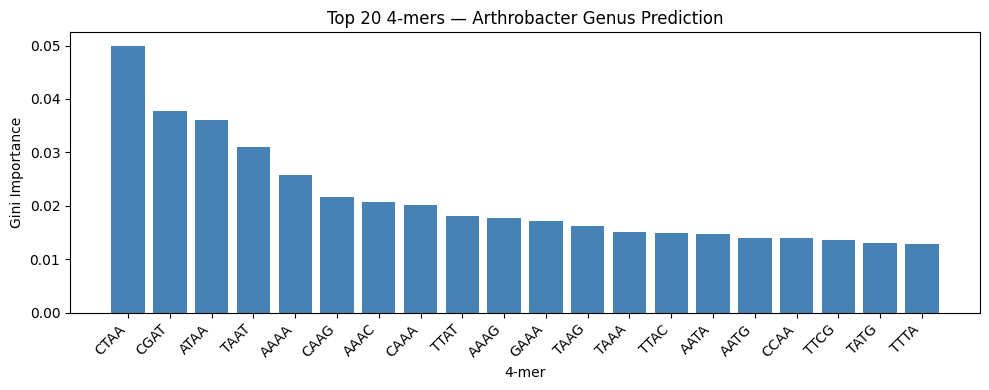

In [16]:
rf_full = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_full.fit(X_genus, y_genus)

top_idx   = np.argsort(rf_full.feature_importances_)[::-1][:20]
top_kmers = [KMERS_4[i] for i in top_idx]
top_vals  = rf_full.feature_importances_[top_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_kmers, top_vals, color='steelblue')
ax.set_xlabel('4-mer')
ax.set_ylabel('Gini Importance')
ax.set_title('Top 20 4-mers — Arthrobacter Genus Prediction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/rf_feature_importance.png', dpi=150)
plt.show()

Tool 3: WISH

In [34]:
import subprocess, os, glob

subprocess.run('apt-get install -qq -y cmake g++ zlib1g-dev', shell=True)
subprocess.run('rm -rf /tmp/WIsH_src', shell=True)
subprocess.run('git clone -q https://github.com/soedinglab/WIsH /tmp/WIsH_src', shell=True)
subprocess.run('cmake -S /tmp/WIsH_src -B /tmp/WIsH_src/build -DCMAKE_BUILD_TYPE=Release', shell=True)
subprocess.run('cmake --build /tmp/WIsH_src/build -j4', shell=True)

result = subprocess.run('find /tmp/WIsH_src/build -type f', shell=True, capture_output=True, text=True)
for f in result.stdout.strip().split('\n'):
    if 'WIsH' in f or 'wish' in f.lower():
        subprocess.run(f'cp "{f}" /usr/local/bin/WIsH && chmod +x /usr/local/bin/WIsH', shell=True)
        print(f'Copied: {f}')
        break

test = subprocess.run(['/usr/local/bin/WIsH'], capture_output=True, text=True)
print('WIsH ready' if test.returncode in (0, 1, 255) else 'WIsH not working')

Copied: /tmp/WIsH_src/build/WIsH
WIsH ready


In [36]:
import subprocess, os, glob

accession = 'GCF_000159075.1'
label     = 'Arthrobacter_sp'
outdir    = f"{dirs['fasta_ref']}/{label}"
zip_path  = f'{outdir}/{accession}.zip'
extract_dir = f'{outdir}/extracted'

os.makedirs(outdir, exist_ok=True)

subprocess.run(
    f'datasets download genome accession {accession} --include genome --filename {zip_path}',
    shell=True, check=True
)

subprocess.run(f'unzip -q -o {zip_path} -d {extract_dir}', shell=True)

# print every file inside
all_files = glob.glob(f'{extract_dir}/**/*', recursive=True)
for f in all_files:
    print(f)

data/fasta_ref_hosts/Arthrobacter_sp/extracted/md5sum.txt
data/fasta_ref_hosts/Arthrobacter_sp/extracted/README.md
data/fasta_ref_hosts/Arthrobacter_sp/extracted/ncbi_dataset
data/fasta_ref_hosts/Arthrobacter_sp/extracted/ncbi_dataset/data
data/fasta_ref_hosts/Arthrobacter_sp/extracted/ncbi_dataset/data/assembly_data_report.jsonl
data/fasta_ref_hosts/Arthrobacter_sp/extracted/ncbi_dataset/data/dataset_catalog.json


In [38]:
import gzip, shutil, glob, subprocess, os
from urllib.request import urlretrieve

label  = 'Arthrobacter_sp'
outdir = f"{dirs['fasta_ref']}/{label}"
fna    = f"{outdir}/{label}.fna"
os.makedirs(outdir, exist_ok=True)

# Clean up failed attempts
shutil.rmtree(f'{outdir}/extracted', ignore_errors=True)
for z in glob.glob(f'{outdir}/*.zip'):
    os.remove(z)

if not os.path.exists(fna):
    # Arthrobacter aurescens TC1 — complete genome, verified FTP path
    url = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/017/325/GCF_000017325.1_ASM1732v1/GCF_000017325.1_ASM1732v1_genomic.fna.gz'
    gz  = f'{outdir}/temp.fna.gz'
    try:
        urlretrieve(url, gz)
        with gzip.open(gz, 'rb') as fin, open(fna, 'wb') as fout:
            shutil.copyfileobj(fin, fout)
        os.remove(gz)
        print(f'{label}: {os.path.getsize(fna)//1000} KB')
    except Exception as e:
        print(f'ERROR: {e}')
        # fallback — Arthrobacter sp. AK1
        url2 = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/001/591/445/GCF_001591445.1_ASM159144v1/GCF_001591445.1_ASM159144v1_genomic.fna.gz'
        try:
            urlretrieve(url2, gz)
            with gzip.open(gz, 'rb') as fin, open(fna, 'wb') as fout:
                shutil.copyfileobj(fin, fout)
            os.remove(gz)
            print(f'{label} (fallback): {os.path.getsize(fna)//1000} KB')
        except Exception as e2:
            print(f'Fallback also failed: {e2}')
else:
    print(f'{label}: already exists ({os.path.getsize(fna)//1000} KB)')

ref_dirs[label] = outdir
print('ref_dirs:', list(ref_dirs.keys()))


Arthrobacter_sp: 5379 KB
ref_dirs: ['Arthrobacter_globiformis', 'Streptomyces_coelicolor', 'Arthrobacter_sp']


In [39]:
def run_cmd(cmd):
    env = {**os.environ, 'PATH': '/usr/local/bin:/usr/bin:/bin'}
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, env=env)
    if r.returncode != 0:
        print(f'ERROR: {r.stdout[:300]}')
    return r.returncode == 0

for label, fdir in ref_dirs.items():
    mdir = f"{dirs['wish_models']}/{label}"
    os.makedirs(mdir, exist_ok=True)
    if not glob.glob(f'{mdir}/*.mm'):
        print(f'Building model for {label}...')
        run_cmd(f'WIsH -c build -g {fdir} -m {mdir}')
    else:
        print(f'{label}: model already exists')

Building model for Arthrobacter_globiformis...
Building model for Streptomyces_coelicolor...
Building model for Arthrobacter_sp...


In [40]:
QUERY_DIR = 'wish_query_phages'
os.makedirs(QUERY_DIR, exist_ok=True)

phage_meta = {}
for name, seq in all_seqs.items():
    out = f'{QUERY_DIR}/{name}.fna'
    if not os.path.exists(out):
        with open(out, 'w') as f:
            f.write(f'>{name}\n{seq}\n')
    phage_meta[name] = all_genus.get(name, 'Unknown')

In [41]:
wish_likelihoods = {}
for label in ref_dirs:
    mdir   = f"{dirs['wish_models']}/{label}"
    outdir = f"{dirs['wish_out']}/{label}"
    os.makedirs(outdir, exist_ok=True)
    ok = run_cmd(f'WIsH -c predict -g {QUERY_DIR} -m {mdir} -r {outdir}')
    if ok:
        ll = f'{outdir}/llikelihood.matrix'
        if os.path.exists(ll):
            df = pd.read_csv(ll, sep='\t', index_col=0)
            wish_likelihoods[label] = df
            print(f'{label}: {df.shape}')
        else:
            print(f'{label}: no output file found in {outdir}')

Arthrobacter_globiformis: (1, 278)
Streptomyces_coelicolor: (1, 278)
Arthrobacter_sp: (1, 278)


In [49]:
# Check what's in the query dir and output dirs
import os, glob

print('Query dir file count:', len(glob.glob(f'{QUERY_DIR}/*.fna')))
print('Sample files:', glob.glob(f'{QUERY_DIR}/*.fna')[:3])
print()

for label in ref_dirs:
    outdir = f"{dirs['wish_out']}/{label}"
    files = os.listdir(outdir) if os.path.exists(outdir) else []
    print(f'{label} output files: {files}')
    ll = f'{outdir}/llikelihood.matrix'
    if os.path.exists(ll):
        import pandas as pd
        df = pd.read_csv(ll, sep='\t', index_col=0)
        print(f'  matrix shape: {df.shape}')
        print(f'  index sample: {df.index.tolist()[:3]}')
        print(f'  columns: {df.columns.tolist()}')
    print()

Query dir file count: 278
Sample files: ['wish_query_phages/Chocolat.fna', 'wish_query_phages/BlackJade.fna', 'wish_query_phages/ChuckDuck.fna']

Arthrobacter_globiformis output files: ['llikelihood.matrix']
  matrix shape: (1, 278)
  index sample: ['Arthrobacter_globiformis']
  columns: ['Chocolat', 'BlackJade', 'ChuckDuck', 'GalaxyEater', 'Flutur', 'CapnMurica', 'Avrafan', 'CookieBear', 'Djungelskog', 'Exile', 'BreSam8', 'Circuit', 'ElectricPheel', 'EstebanJulior', 'BarbieDoll', 'Berka', 'FloraSnap32', 'BlueShadow', 'Chickaboom', 'Andrew', 'Copper', 'Beans', 'BigMack', 'Brunswick', 'AllBusiness', 'Eyoseyas', 'Chamuel', 'BruhMoment', 'CallieOMalley', 'ApoKipo', 'Galaxy', 'BossLady', 'Altjira', 'BellaJr', 'Elfy', 'Forrestell', 'EhyElimayoE', 'BlueFeather', 'Acai', 'AmiCi24', 'BaileyBlu', 'Colleen', 'DreamTeam1', 'Cote', 'Fingolfin', 'Bennie', 'ERHickory', 'BrotherBLo', 'Adaia', 'DoctorPepper', 'Benry', 'Adat', 'Boersma', 'Arzan', 'Elver', 'EdgarPoe', 'EvePickles', 'Arlo', 'Argan', 'Cha

In [51]:
frames = []
for label, df in wish_likelihoods.items():
    df_t = df.T
    df_t.index = df_t.index.str.replace('.fna', '', regex=False)
    df_t.columns = df_t.columns.str.replace('.fna', '', regex=False)
    df_t = df_t.rename(columns={df_t.columns[0]: label})
    frames.append(df_t)

if not frames:
    print('No WIsH output found')
    wish_scores = pd.DataFrame()
else:
    wish_scores = pd.concat(frames, axis=1)
    print('Shape:', wish_scores.shape)
    print('Columns:', wish_scores.columns.tolist())

arth_cols  = [c for c in wish_scores.columns if 'Arthrobacter' in c]
other_cols = [c for c in wish_scores.columns if 'Arthrobacter' not in c]
print('Arthrobacter cols:', arth_cols)
print('Other cols:', other_cols)

Shape: (278, 3)
Columns: ['Arthrobacter_globiformis', 'Streptomyces_coelicolor', 'Arthrobacter_sp']
Arthrobacter cols: ['Arthrobacter_globiformis', 'Arthrobacter_sp']
Other cols: ['Streptomyces_coelicolor']


In [52]:
wish_genus_preds = {}
for phage in wish_scores.index:
    if phage not in phage_meta:
        continue
    a = wish_scores.loc[phage, arth_cols].max() if arth_cols else -9999
    o = wish_scores.loc[phage, other_cols].max() if other_cols else -9999
    wish_genus_preds[phage] = 1 if a >= o else 0

cn      = [n for n in wish_genus_preds if n in phage_meta]
wg_true = [1 if phage_meta[n] == 'Arthrobacter' else 0 for n in cn]
wg_pred = [wish_genus_preds[n] for n in cn]

wish_genus_metrics = {
    'Top-1 Accuracy': round(accuracy_score(wg_true, wg_pred), 3),
    'Macro F1': round(f1_score(wg_true, wg_pred, average='macro', zero_division=0), 3),
    'n': len(cn), 'y_true': wg_true, 'y_pred': wg_pred,
}
print('WIsH genus:', {k:v for k,v in wish_genus_metrics.items() if k not in ('y_true','y_pred')})

WIsH genus: {'Top-1 Accuracy': 0.353, 'Macro F1': 0.339, 'n': 278}


In [53]:
glob_col = 'Arthrobacter_globiformis'
sp_col   = 'Arthrobacter_sp'
wish_sp_preds = {}

for phage in wish_scores.index:
    sp = arth_species_labels.get(phage)
    if sp is None:
        continue
    if glob_col in wish_scores.columns and sp_col in wish_scores.columns:
        wish_sp_preds[phage] = (
            1 if wish_scores.loc[phage, glob_col] >= wish_scores.loc[phage, sp_col] else 0,
            sp
        )

ws_true = [1 if v[1].lower() == 'globiformis' else 0 for v in wish_sp_preds.values()]
ws_pred = [v[0] for v in wish_sp_preds.values()]

wish_species_metrics = {
    'Top-1 Accuracy': round(accuracy_score(ws_true, ws_pred), 3) if ws_true else 0,
    'Macro F1': round(f1_score(ws_true, ws_pred, average='macro', zero_division=0), 3) if ws_true else 0,
    'n': len(ws_true), 'y_true': ws_true, 'y_pred': ws_pred,
}
print('WIsH species:', {k:v for k,v in wish_species_metrics.items() if k not in ('y_true','y_pred')})

WIsH species: {'Top-1 Accuracy': 0.623, 'Macro F1': 0.473, 'n': 244}


Results

In [54]:
def get(m, k, fallback='N/A'):
    return m.get(k, fallback) if m else fallback

rows_genus = [
    {'Tool': 'PHASTEST',  'Top-1 Acc': get(phastest_genus_metrics,'Top-1 Accuracy'),
     'Macro F1': get(phastest_genus_metrics,'Macro F1'), 'Runtime/genome': 'API'},
    {'Tool': 'k-mer RF',  'Top-1 Acc': get(rf_genus_metrics,'Top-1 Accuracy'),
     'Macro F1': get(rf_genus_metrics,'Macro F1'), 'Runtime/genome': get(rf_genus_metrics,'Runtime/genome')},
    {'Tool': 'WIsH',      'Top-1 Acc': get(wish_genus_metrics,'Top-1 Accuracy'),
     'Macro F1': get(wish_genus_metrics,'Macro F1'), 'Runtime/genome': '<0.01'},
]
rows_species = [
    {'Tool': 'PHASTEST',  'Top-1 Acc': get(phastest_species_metrics,'Top-1 Accuracy'),
     'Macro F1': 'N/A', 'Runtime/genome': 'API'},
    {'Tool': 'k-mer RF',  'Top-1 Acc': get(rf_species_metrics,'Top-1 Accuracy'),
     'Macro F1': get(rf_species_metrics,'Macro F1'), 'Runtime/genome': get(rf_species_metrics,'Runtime/genome')},
    {'Tool': 'WIsH',      'Top-1 Acc': get(wish_species_metrics,'Top-1 Accuracy'),
     'Macro F1': get(wish_species_metrics,'Macro F1'), 'Runtime/genome': '<0.01'},
]

df_genus   = pd.DataFrame(rows_genus).set_index('Tool')
df_species = pd.DataFrame(rows_species).set_index('Tool')

print('Genus-level results:')
print(df_genus.to_string())
print()
print('Species-level results:')
print(df_species.to_string())

df_genus.to_csv('results/table2_genus.csv')
df_species.to_csv('results/table3_species.csv')

Genus-level results:
          Top-1 Acc  Macro F1 Runtime/genome
Tool                                        
PHASTEST      0.111     0.100            API
k-mer RF      0.942     0.841         0.0308
WIsH          0.353     0.339          <0.01

Species-level results:
          Top-1 Acc Macro F1 Runtime/genome
Tool                                       
PHASTEST      0.000      N/A            API
k-mer RF      0.922    0.918         0.0365
WIsH          0.623    0.473          <0.01


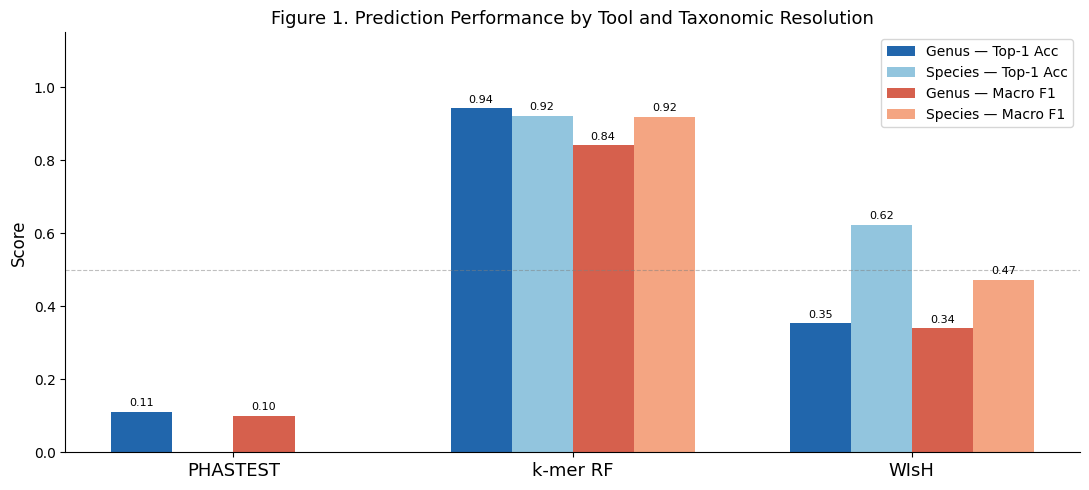

In [55]:
def to_float(v):
    try: return float(v)
    except: return 0.0

tools_plot   = ['PHASTEST', 'k-mer RF', 'WIsH']
genus_top1   = [to_float(get(phastest_genus_metrics,'Top-1 Accuracy')),
                to_float(get(rf_genus_metrics,'Top-1 Accuracy')),
                to_float(get(wish_genus_metrics,'Top-1 Accuracy'))]
species_top1 = [to_float(get(phastest_species_metrics,'Top-1 Accuracy')),
                to_float(get(rf_species_metrics,'Top-1 Accuracy')),
                to_float(get(wish_species_metrics,'Top-1 Accuracy'))]
genus_f1     = [to_float(get(phastest_genus_metrics,'Macro F1')),
                to_float(get(rf_genus_metrics,'Macro F1')),
                to_float(get(wish_genus_metrics,'Macro F1'))]
species_f1   = [to_float(get(phastest_species_metrics,'Macro F1')),
                to_float(get(rf_species_metrics,'Macro F1')),
                to_float(get(wish_species_metrics,'Macro F1'))]

x = np.arange(len(tools_plot))
w = 0.18
colors = ['#2166AC', '#92C5DE', '#D6604D', '#F4A582']

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-1.5*w, genus_top1,   w, label='Genus — Top-1 Acc',   color=colors[0])
b2 = ax.bar(x-0.5*w, species_top1, w, label='Species — Top-1 Acc', color=colors[1])
b3 = ax.bar(x+0.5*w, genus_f1,     w, label='Genus — Macro F1',    color=colors[2])
b4 = ax.bar(x+1.5*w, species_f1,   w, label='Species — Macro F1',  color=colors[3])

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(tools_plot, fontsize=13)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 1. Prediction Performance by Tool and Taxonomic Resolution', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('figures/figure1_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

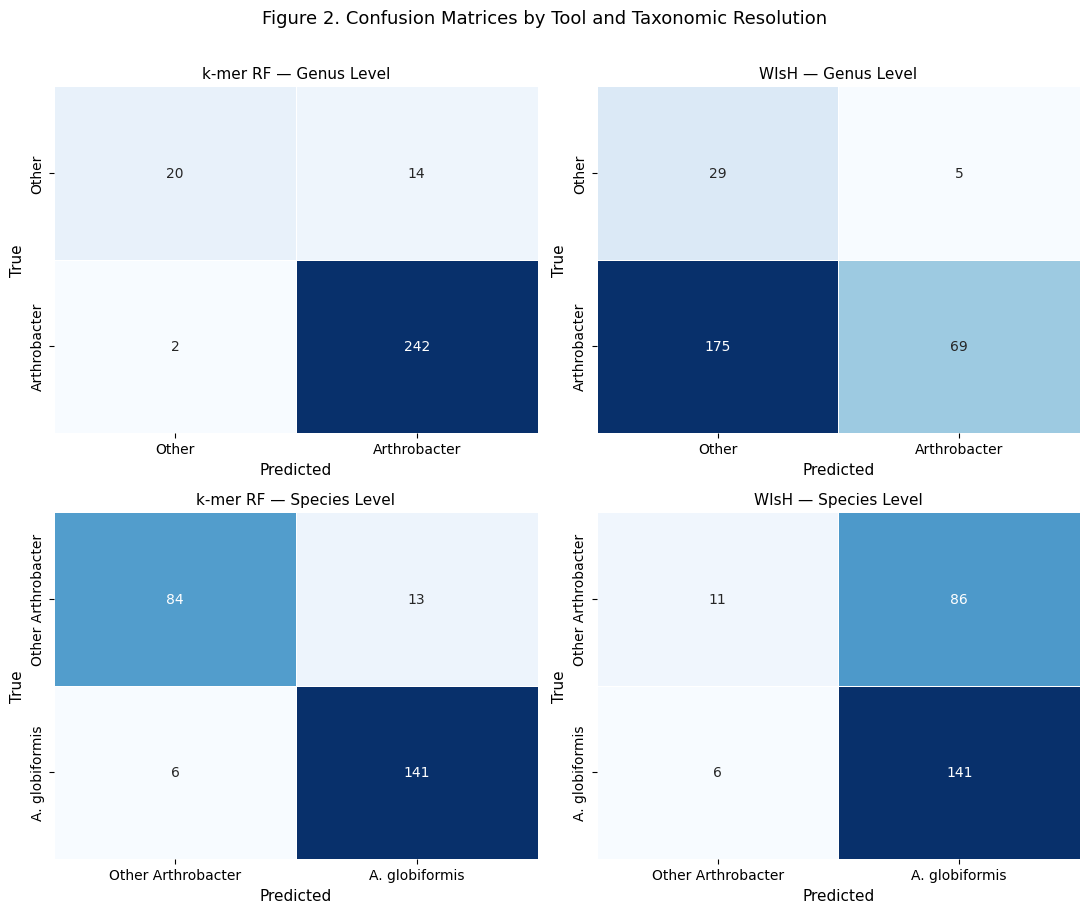

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

def plot_cm(ax, y_true, y_pred, title, labels=None):
    if not y_true:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    labels = labels or ['Other', 'Arthrobacter']
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels,
                cmap='Blues', cbar=False, linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=11)

plot_cm(axes[0,0],
        list(rf_genus_metrics.get('y_true',[])) if rf_genus_metrics else [],
        list(rf_genus_metrics.get('y_pred',[])) if rf_genus_metrics else [],
        'k-mer RF — Genus Level')

plot_cm(axes[0,1],
        wish_genus_metrics.get('y_true',[]),
        wish_genus_metrics.get('y_pred',[]),
        'WIsH — Genus Level')

sp_labels = ['Other Arthrobacter', 'A. globiformis']
plot_cm(axes[1,0],
        list(rf_species_metrics.get('y_true',[])) if rf_species_metrics else [],
        list(rf_species_metrics.get('y_pred',[])) if rf_species_metrics else [],
        'k-mer RF — Species Level', labels=sp_labels)

plot_cm(axes[1,1],
        wish_species_metrics.get('y_true',[]),
        wish_species_metrics.get('y_pred',[]),
        'WIsH — Species Level', labels=sp_labels)

fig.suptitle('Figure 2. Confusion Matrices by Tool and Taxonomic Resolution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/figure2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

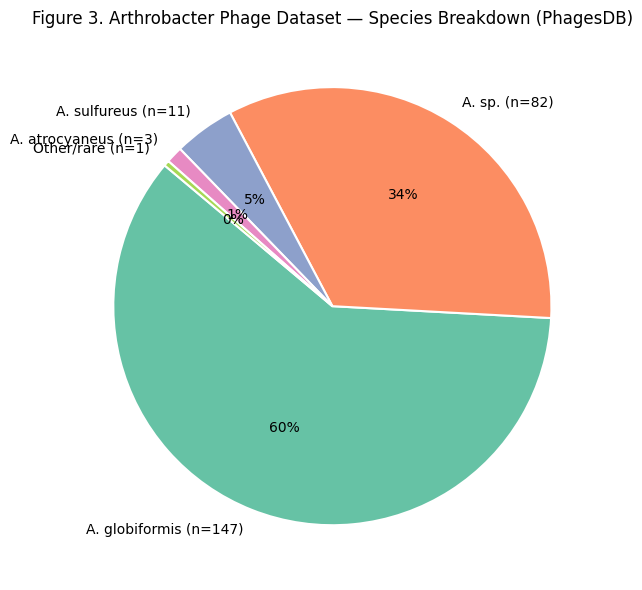

In [57]:
sp_counts = Counter(arth_species_labels.values())
labels_pie, sizes_pie, other_count = [], [], 0
for sp, ct in sp_counts.most_common():
    display = sp if sp else '(unspecified)'
    if ct >= 3:
        labels_pie.append(f'A. {display} (n={ct})')
        sizes_pie.append(ct)
    else:
        other_count += ct
if other_count:
    labels_pie.append(f'Other/rare (n={other_count})')
    sizes_pie.append(other_count)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes_pie, labels=labels_pie, autopct='%1.0f%%',
       wedgeprops={'edgecolor':'white','linewidth':1.5},
       startangle=140, colors=plt.cm.Set2.colors)
ax.set_title('Figure 3. Arthrobacter Phage Dataset — Species Breakdown (PhagesDB)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/figure3_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()